# 6CS012 - Worksheet 5
## End-to-End CNN Model for Image Classification (Amazon Fruits Dataset)
---

## Setup & Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

# Paths - update these to match your dataset location
train_dir = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train'
test_dir  = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/test'

# Hyperparameters
IMG_HEIGHT    = 128
IMG_WIDTH     = 128
BATCH_SIZE    = 16
EPOCHS        = 250
VALIDATION_SPLIT = 0.2
SEED          = 123

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


---
## Task 1: Data Understanding and Visualization

### 1a. Visualize one image per class in a grid

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


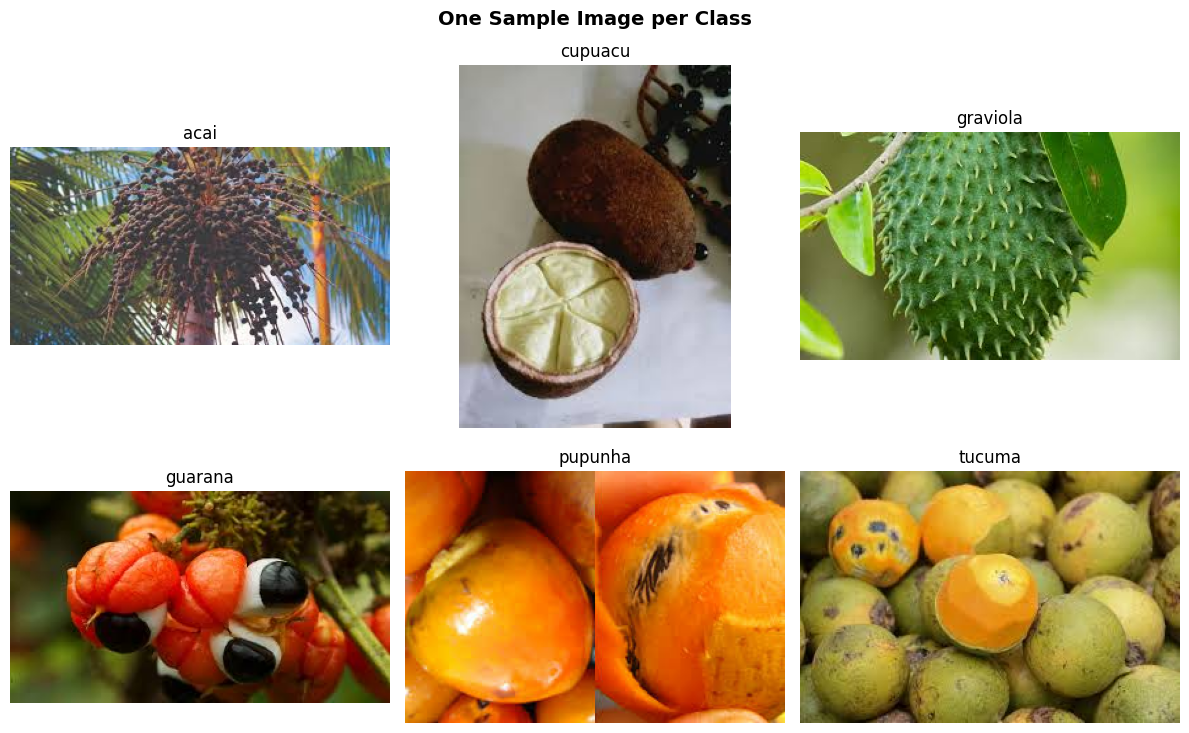


Observations:
- The dataset contains 6 Amazon fruit classes: pupunha, guarana, graviola, tucuma, acai, cupuacu.
- Images vary significantly in size, background, lighting, and color.
- Some classes (e.g., acai) have very distinct colors; others may be harder to distinguish.
- Preprocessing (resize + normalize) is essential before training.



In [8]:
# Get class directories from train folder
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
num_classes = len(class_dirs)
print(f'Classes found ({num_classes}):', class_dirs)

# Select one random image per class
sample_images = []
sample_labels = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        chosen = random.choice(images)
        sample_images.append(os.path.join(cls_path, chosen))
        sample_labels.append(cls)

# Display in a 2-row grid
cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=12)
    axes[i].axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('One Sample Image per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observations:
- The dataset contains 6 Amazon fruit classes: pupunha, guarana, graviola, tucuma, acai, cupuacu.
- Images vary significantly in size, background, lighting, and color.
- Some classes (e.g., acai) have very distinct colors; others may be harder to distinguish.
- Preprocessing (resize + normalize) is essential before training.
""")

### 1b. Check for and Remove Corrupted Images

In [9]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()          # Checks file integrity
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f'Removed corrupted image: {img_path}')

if not corrupted:
    print('No Corrupted Images Found.')
else:
    print(f'Total corrupted images removed: {len(corrupted)}')

No Corrupted Images Found.


---
## Task 2: Loading and Preprocessing Image Data

In [11]:
rescale = tf.keras.layers.Rescaling(1.0 / 255)  # Normalize to [0, 1]

# Training dataset
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)
train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset (no split needed)
raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = raw_test_ds.map(lambda x, y: (rescale(x), y))

# Class names from the dataset
class_names = raw_train_ds.class_names
num_classes = len(class_names)
print('Class names:', class_names)
print('Number of classes:', num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


---
## Task 3: Build the CNN Model

In [12]:
model = keras.Sequential([
    # ── Convolutional Block 1 ──────────────────────────────────
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                  strides=1, activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Convolutional Block 2 ──────────────────────────────────
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                  strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ── Fully Connected Network ────────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),   # Hidden Layer 1
    layers.Dense(64,  activation='relu'),   # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
], name='Fruits_CNN')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fruits_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile and Train the Model

In [13]:
# ── Compile ───────────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,          # Stop if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

# ── Train ─────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.1181 - loss: 2.4409
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 654ms/step - accuracy: 0.1528 - loss: 2.4102 - val_accuracy: 0.0000e+00 - val_loss: 1.6918
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.1920 - loss: 1.7973
Epoch 2: val_accuracy improved from 0.00000 to 0.83333, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 352ms/step - accuracy: 0.2778 - loss: 1.7353 - val_accuracy: 0.8333 - val_loss: 1.4478
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5955 - loss: 1.5712
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 363ms/step - accuracy: 0.5139 - loss: 1.5206 - val_accuracy: 0.6111 - val_loss: 1.3448
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.4778 - loss: 1.3104
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.5139 - loss: 1.2673 - val_accuracy: 0.8333 - val_loss: 0.7747
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8431 - loss: 0.9230
Epoch 5: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.8194 - loss: 0.8784 - val_accuracy: 0.8333 - val_loss: 0.8304
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.8587 - loss: 0.579


Epoch 10: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 349ms/step - accuracy: 1.0000 - loss: 0.0830 - val_accuracy: 0.8889 - val_loss: 0.4754
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 1.0000 - loss: 0.0302
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 1.0000 - loss: 0.0313 - val_accuracy: 0.8889 - val_loss: 0.3359
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 1.0000 - loss: 0.0283
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 1.0000 - loss: 0.0242 - val_accuracy: 0.8333 - val_loss: 0.3911
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 1.0000 - loss: 0.0157
Epoch 13: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 1.0000 - loss: 0.0177 - val_accuracy: 0.8333 - val_loss: 0.4112
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 1.0000 - los


Epoch 20: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 346ms/step - accuracy: 1.0000 - loss: 7.5533e-04 - val_accuracy: 0.9444 - val_loss: 0.2961
Epoch 21/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 1.0000 - loss: 5.6221e-04
Epoch 21: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 1.0000 - loss: 5.6184e-04 - val_accuracy: 0.9444 - val_loss: 0.3035
Epoch 22/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 1.0000 - loss: 3.2269e-04
Epoch 22: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 533ms/step - accuracy: 1.0000 - loss: 4.0369e-04 - val_accuracy: 0.9444 - val_loss: 0.3113
Epoch 23/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 1.0000 - loss: 3.2276e-04
Epoch 23: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 1.0000 - loss: 3.1934e-04 - val_accuracy: 0.9444 - val_loss: 0.3180
Epoch 24/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/s

### Plot Training History

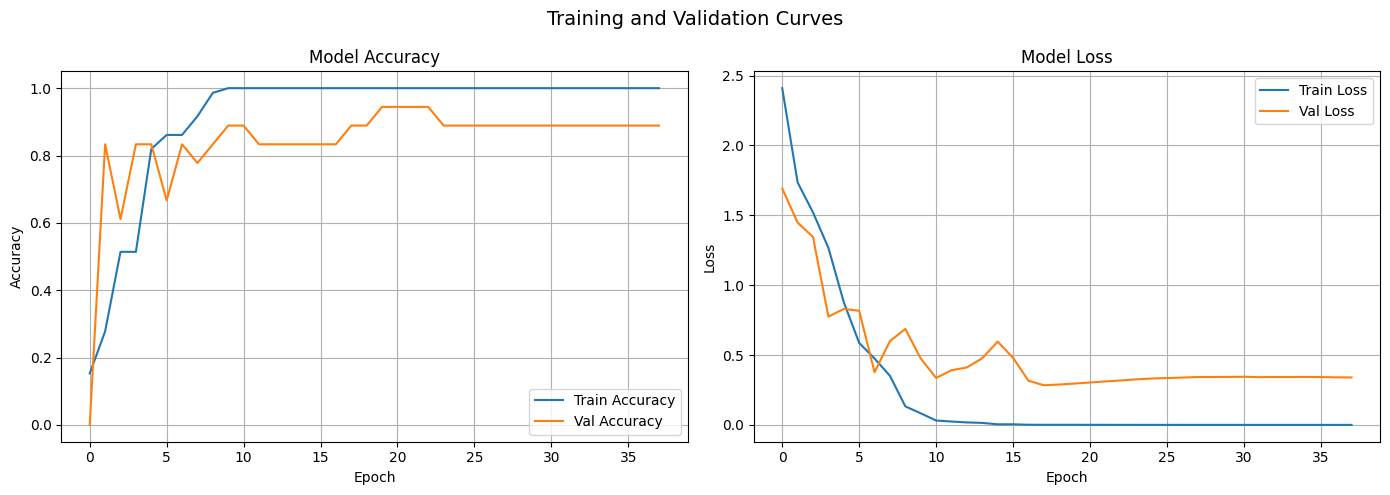

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training and Validation Curves', fontsize=14)
plt.tight_layout()
plt.show()

---
## Task 5: Evaluate the Model

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8000 - loss: 0.8263

Test Loss    : 0.8263
Test Accuracy: 0.8000


---
## Task 6: Save and Load the Model

In [16]:
# Save
model.save('fruits_cnn_model.h5')
print('Model saved as fruits_cnn_model.h5')

# Load
loaded_model = keras.models.load_model('fruits_cnn_model.h5')
print('Model loaded successfully!')

# Re-evaluate with loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f'\nLoaded Model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}')

Model saved as fruits_cnn_model.h5
Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8000 - loss: 0.8263

Loaded Model — Test Loss: 0.8263 | Test Accuracy: 0.8000


---
## Task 7: Predictions and Classification Report

In [17]:
# Collect all true labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print('\n── Classification Report ──────────────────────────────\n')
print(classification_report(y_true, y_pred, target_names=class_names))


── Classification Report ──────────────────────────────

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.62      1.00      0.77         5
     guarana       0.83      1.00      0.91         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.86      0.80      0.79        30
weighted avg       0.86      0.80      0.79        30



### Visualise a Sample of Predictions

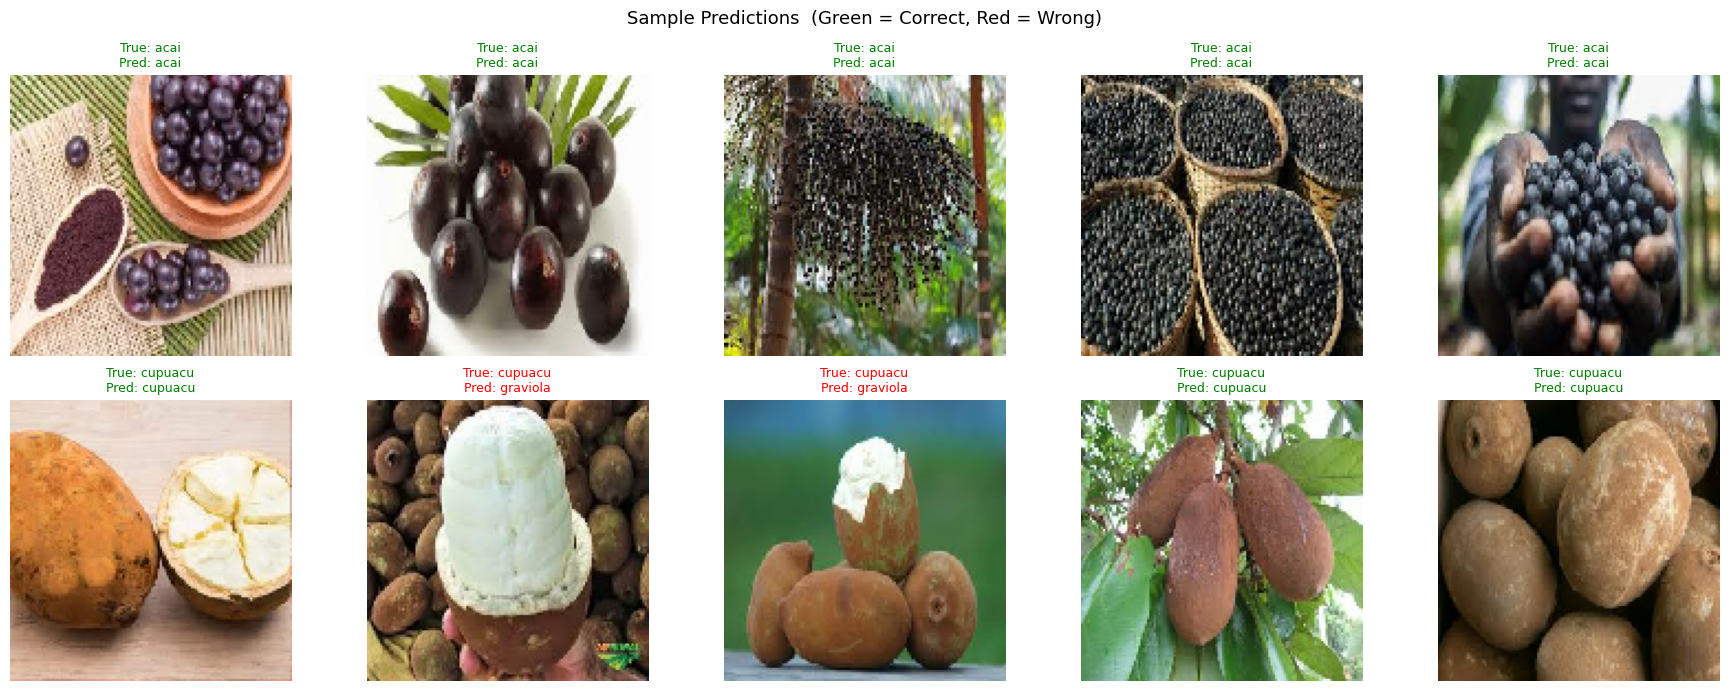

In [18]:
# Show first 10 test images with predicted vs true label
sample_images_batch, sample_labels_batch = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images_batch, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(sample_images_batch[i].numpy())
    true_lbl = class_names[sample_labels_batch[i]]
    pred_lbl = class_names[sample_pred_labels[i]]
    color = 'green' if true_lbl == pred_lbl else 'red'
    axes[i].set_title(f'True: {true_lbl}\nPred: {pred_lbl}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Predictions  (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()